<a href="https://colab.research.google.com/github/tanish19078/tomato-disease-detector/blob/main/tomato_disease_detector_TRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 -q

import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


PyTorch: 2.10.0+cu128
CUDA available: True
Device: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/dataset", exist_ok=True)

# Copy dataset from Drive shortcut
!cp -r "/content/drive/MyDrive/Tomato_Caption"/* /content/dataset/

# Verify
for d in sorted(os.listdir("/content/dataset")):
    full = os.path.join("/content/dataset", d)
    if os.path.isdir(full):
        print(f"  {d}: {len(os.listdir(full))} images")


Mounted at /content/drive
  Tomato___Bacterial_spot: 2624 images
  Tomato___Early_blight: 2408 images
  Tomato___Late_blight: 2616 images
  Tomato___Septoria_leaf_spot: 2392 images
  Tomato___healthy: 3789 images


PyTorch Version: 2.10.0+cu128
Using Device: cuda
Dataset directory already exists. Skipping extraction.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']
Splits: {'train': 11063, 'val': 1382, 'test': 1384}
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 198MB/s]


Epoch 1/15
------------------------------
  train Loss: 0.3215  Acc: 0.8803
  val   Loss: 0.1142  Acc: 0.9530
  *** New best val acc: 0.9530 ***

Epoch 2/15
------------------------------
  train Loss: 0.1441  Acc: 0.9441
  val   Loss: 0.0980  Acc: 0.9653
  *** New best val acc: 0.9653 ***

Epoch 3/15
------------------------------
  train Loss: 0.1130  Acc: 0.9531
  val   Loss: 0.0887  Acc: 0.9602

Epoch 4/15
------------------------------
  train Loss: 0.1117  Acc: 0.9540
  val   Loss: 0.0810  Acc: 0.9580

Epoch 5/15
------------------------------
  train Loss: 0.0889  Acc: 0.9621
  val   Loss: 0.0728  Acc: 0.9602

Epoch 6/15
------------------------------
  train Loss: 0.0848  Acc: 0.9629
  val   Loss: 0.0693  Acc: 0.9747
  *** New best val acc: 0.9747 ***

Epoch 7/15
------------------------------
  train Loss: 0.0827  Acc: 0.9648
  val   Loss: 0.0711  Acc: 0.9711

Epoch 8/15
------------------------------
  train Loss: 0.0690  Acc: 0.9698
  val   Loss: 0.0484  Acc: 0.9740

Epoch 9

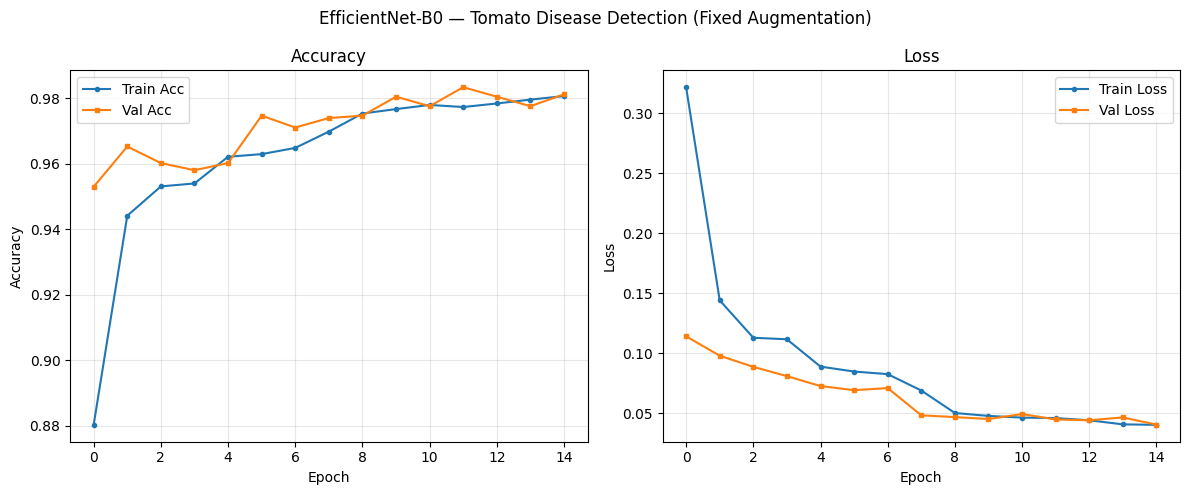

Saved training curves plot.

Test Set Accuracy: 0.9841 (1362/1384)


ModuleNotFoundError: No module named 'onnxscript'

In [ ]:
"""
Tomato Leaf Disease Detection — EfficientNet-B0 Training Script (FIXED)
========================================================================
Fix: Uses a TransformSubset wrapper so train/val/test each get their own
     transforms, instead of mutating the shared dataset object.

Run on Google Colab with T4 GPU:
  1. Upload the 5 zip files to /content/
  2. Run this script
  3. Download the .onnx, .onnx.data, and class_mapping.json files
"""

import os
import time
import copy
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision
from torchvision import datasets, transforms, models

print("PyTorch Version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)


# ─── 1. Dataset Setup ────────────────────────────────────────────────────

# === FIX: Wrapper class that applies its OWN transform to a Subset ===
class TransformSubset(Dataset):
    """
    Wraps a torch.utils.data.Subset with a custom transform.
    This avoids the bug where setting .dataset.transform mutates
    the shared parent dataset for ALL subsets.
    """
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.subset[index]
        # subset returns already-transformed data if parent has a transform,
        # so we need raw images. We access the underlying dataset directly.
        raw_img, label = self.subset.dataset.samples[self.subset.indices[index]]
        from PIL import Image
        img = Image.open(raw_img).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)


# Unzip data if needed
data_dir = "/content/dataset"
if not os.path.exists(data_dir):
    import glob, zipfile
    os.makedirs(data_dir)
    print("Unzipping dataset files...")
    for zip_file in glob.glob("/content/*.zip"):
        print(f"  Extracting {zip_file}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
    print("Finished unzipping!")
else:
    print("Dataset directory already exists. Skipping extraction.")


input_size = 224
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset WITHOUT transform — raw images
full_dataset = datasets.ImageFolder(data_dir, transform=None)

# 80/10/10 split
total_len = len(full_dataset)
train_len = int(0.8 * total_len)
val_len = int(0.1 * total_len)
test_len = total_len - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42)
)

# === FIX: Wrap each subset with its own transform ===
train_data = TransformSubset(train_subset, train_transform)
val_data = TransformSubset(val_subset, val_transform)
test_data = TransformSubset(test_subset, val_transform)

dataloaders = {
    'train': DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2),
    'val': DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2),
    'test': DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)
}
dataset_sizes = {'train': len(train_data), 'val': len(val_data), 'test': len(test_data)}
class_names = full_dataset.classes

print(f"Classes: {class_names}")
print(f"Splits: {dataset_sizes}")


# ─── 2. Model Definition ─────────────────────────────────────────────────

def initialize_model(num_classes, feature_extract=False):
    model_ft = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    if feature_extract:
        for param in model_ft.parameters():
            param.requires_grad = False

    # Custom classifier head with MC Dropout
    num_ftrs = model_ft.classifier[1].in_features
    model_ft.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(num_ftrs, num_classes)
    )
    return model_ft


model_ft = initialize_model(num_classes=len(class_names), feature_extract=False)
model_ft = model_ft.to(device)


# ─── 3. Training Configuration ───────────────────────────────────────────

optimizer_ft = optim.AdamW(model_ft.parameters(), lr=5.97e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


# ─── 4. Training Loop ────────────────────────────────────────────────────

def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=20):
    since = time.time()
    val_acc_history = []
    train_acc_history = []
    train_loss_history = []
    val_loss_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                train_acc_history.append(epoch_acc.item())
                train_loss_history.append(epoch_loss)
            else:
                val_acc_history.append(epoch_acc.item())
                val_loss_history.append(epoch_loss)

            print(f'  {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'  *** New best val acc: {best_acc:.4f} ***')
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history, train_loss_history, val_loss_history


NUM_EPOCHS = 15
model_ft, t_acc, v_acc, t_loss, v_loss = train_model(
    model_ft, dataloaders, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS
)

torch.save(model_ft.state_dict(), "best_efficientnet_tomato.pth")
print("Saved best_efficientnet_tomato.pth")


# ─── 5. Plot Training Curves ─────────────────────────────────────────────

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_acc, label="Train Acc", marker='o', markersize=3)
plt.plot(v_acc, label="Val Acc", marker='s', markersize=3)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t_loss, label="Train Loss", marker='o', markersize=3)
plt.plot(v_loss, label="Val Loss", marker='s', markersize=3)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("EfficientNet-B0 — Tomato Disease Detection (Fixed Augmentation)")
plt.tight_layout()
plt.savefig("efficientnet_b0_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved training curves plot.")


# ─── 6. Test Set Evaluation ──────────────────────────────────────────────

model_ft.eval()
test_corrects = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)
        test_total += labels.size(0)

test_acc = test_corrects.double() / test_total
print(f"\nTest Set Accuracy: {test_acc:.4f} ({test_corrects}/{test_total})")


# ─── 7. ONNX Export ──────────────────────────────────────────────────────

model_ft.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model_ft,
    dummy_input,
    "tomato_disease_efficientnet.onnx",
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

# Save class mapping
with open("class_mapping.json", "w") as f:
    json.dump({k: v for k, v in enumerate(class_names)}, f)

print("\nExported to ONNX successfully!")
print("Files to download:")
print("  - tomato_disease_efficientnet.onnx")
print("  - tomato_disease_efficientnet.onnx.data")
print("  - class_mapping.json")
print("  - best_efficientnet_tomato.pth")
print("  - efficientnet_b0_training_curves.png")


In [ ]:
!pip install onnxscript onnx -q

import torch, json

model_ft.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model_ft,
    dummy_input,
    "tomato_disease_efficientnet.onnx",
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

class_names = ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']
with open("class_mapping.json", "w") as f:
    json.dump({k: v for k, v in enumerate(class_names)}, f)

print("ONNX export done!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.3 MB/s eta 0:00:00


/tmp/ipykernel_1823/3555652117.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0425 05:55:09.043000 1823 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0425 05:55:09.044000 1823 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0425 05:55:09.046000 1823 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: '

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX export done!


In [ ]:
from google.colab import files
files.download("tomato_disease_efficientnet.onnx")
files.download("class_mapping.json")
files.download("best_efficientnet_tomato.pth")
files.download("efficientnet_b0_training_curves.png")
files.download("tomato_disease_efficientnet.onnx.data")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PyTorch Version: 2.10.0+cu128
Using Device: cuda
Dataset directory already exists. Skipping extraction.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']
Splits: {'train': 11063, 'val': 1382, 'test': 1384}
Epoch 1/15
------------------------------
  train Loss: 0.3987  Acc: 0.8549
  val   Loss: 0.1879  Acc: 0.9370
  *** New best val acc: 0.9370 ***

Epoch 2/15
------------------------------
  train Loss: 0.1712  Acc: 0.9370
  val   Loss: 0.1578  Acc: 0.9385
  *** New best val acc: 0.9385 ***

Epoch 3/15
------------------------------
  train Loss: 0.1605  Acc: 0.9422
  val   Loss: 0.1018  Acc: 0.9660
  *** New best val acc: 0.9660 ***

Epoch 4/15
------------------------------
  train Loss: 0.1104  Acc: 0.9555
  val   Loss: 0.1038  Acc: 0.9522

Epoch 5/15
------------------------------
  train Loss: 0.1157  Acc: 0.9538
  val   Loss: 0.1285  Acc: 0.9465

Epoch 6/15
------------------------------
  tra

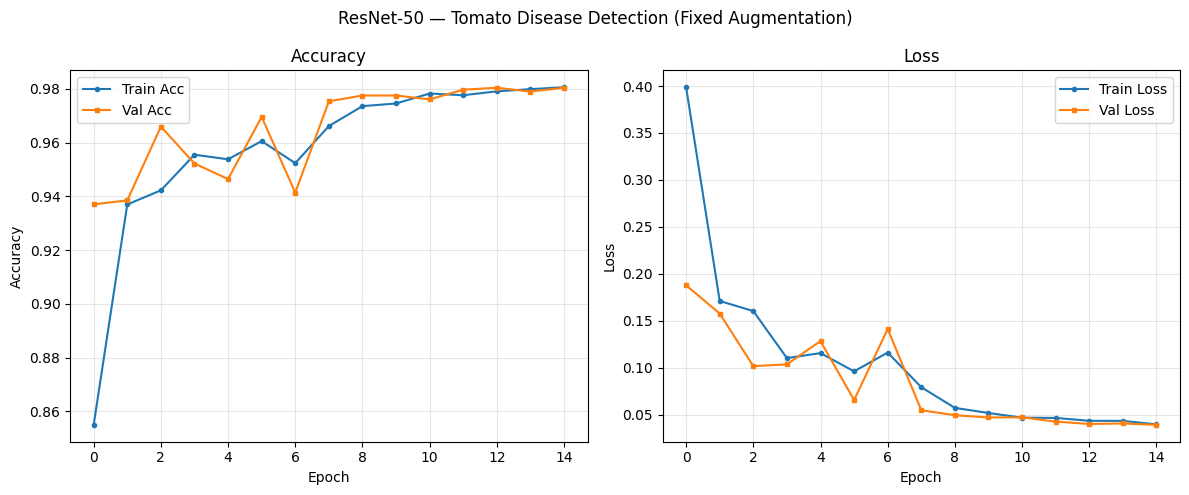

Saved training curves plot.

Test Set Accuracy: 0.9812 (1358/1384)


/tmp/ipykernel_1823/2870280579.py:287: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0425 06:34:05.284000 1823 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0425 06:34:05.287000 1823 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0425 06:34:05.291000 1823 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale:

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅

Exported to ONNX successfully!
Files to download:
  - tomato_disease_resnet50.onnx
  - tomato_disease_resnet50.onnx.data
  - class_mapping_resnet.json
  - best_resnet50_tomato.pth
  - resnet50_training_curves.png


In [ ]:
"""
Tomato Leaf Disease Detection — ResNet-50 Training Script (FIXED)
==================================================================
Fix: Uses a TransformSubset wrapper so train/val/test each get their own
     transforms, instead of mutating the shared dataset object.

Run on Google Colab with T4 GPU:
  1. Upload the 5 zip files to /content/
  2. Run this script
  3. Download the .onnx, .onnx.data, and class_mapping_resnet.json files
"""

import os
import time
import copy
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision
from torchvision import datasets, transforms, models

print("PyTorch Version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)


# ─── 1. Dataset Setup ────────────────────────────────────────────────────

# === FIX: Wrapper class that applies its OWN transform to a Subset ===
class TransformSubset(Dataset):
    """
    Wraps a torch.utils.data.Subset with a custom transform.
    This avoids the bug where setting .dataset.transform mutates
    the shared parent dataset for ALL subsets.
    """
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        # Access raw image path and label from the underlying dataset
        raw_img_path, label = self.subset.dataset.samples[self.subset.indices[index]]
        from PIL import Image
        img = Image.open(raw_img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)


# Unzip data if needed
data_dir = "/content/dataset"
if not os.path.exists(data_dir):
    import glob, zipfile
    os.makedirs(data_dir)
    print("Unzipping dataset files...")
    for zip_file in glob.glob("/content/*.zip"):
        print(f"  Extracting {zip_file}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
    print("Finished unzipping!")
else:
    print("Dataset directory already exists. Skipping extraction.")


input_size = 224
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset WITHOUT transform — raw images
full_dataset = datasets.ImageFolder(data_dir, transform=None)

# 80/10/10 split
total_len = len(full_dataset)
train_len = int(0.8 * total_len)
val_len = int(0.1 * total_len)
test_len = total_len - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42)
)

# === FIX: Wrap each subset with its own transform ===
train_data = TransformSubset(train_subset, train_transform)
val_data = TransformSubset(val_subset, val_transform)
test_data = TransformSubset(test_subset, val_transform)

dataloaders = {
    'train': DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2),
    'val': DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2),
    'test': DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)
}
dataset_sizes = {'train': len(train_data), 'val': len(val_data), 'test': len(test_data)}
class_names = full_dataset.classes

print(f"Classes: {class_names}")
print(f"Splits: {dataset_sizes}")


# ─── 2. Model Definition ─────────────────────────────────────────────────

def initialize_model(num_classes, feature_extract=False):
    model_ft = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    if feature_extract:
        for param in model_ft.parameters():
            param.requires_grad = False

    # ResNet uses '.fc' for its final head
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(num_ftrs, num_classes)
    )
    return model_ft


model_ft = initialize_model(num_classes=len(class_names), feature_extract=False)
model_ft = model_ft.to(device)


# ─── 3. Training Configuration ───────────────────────────────────────────

optimizer_ft = optim.AdamW(model_ft.parameters(), lr=5.97e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


# ─── 4. Training Loop ────────────────────────────────────────────────────

def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=20):
    since = time.time()
    val_acc_history = []
    train_acc_history = []
    train_loss_history = []
    val_loss_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                train_acc_history.append(epoch_acc.item())
                train_loss_history.append(epoch_loss)
            else:
                val_acc_history.append(epoch_acc.item())
                val_loss_history.append(epoch_loss)

            print(f'  {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'  *** New best val acc: {best_acc:.4f} ***')
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history, train_loss_history, val_loss_history


NUM_EPOCHS = 15
model_ft, t_acc, v_acc, t_loss, v_loss = train_model(
    model_ft, dataloaders, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS
)

torch.save(model_ft.state_dict(), "best_resnet50_tomato.pth")
print("Saved best_resnet50_tomato.pth")


# ─── 5. Plot Training Curves ─────────────────────────────────────────────

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_acc, label="Train Acc", marker='o', markersize=3)
plt.plot(v_acc, label="Val Acc", marker='s', markersize=3)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t_loss, label="Train Loss", marker='o', markersize=3)
plt.plot(v_loss, label="Val Loss", marker='s', markersize=3)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("ResNet-50 — Tomato Disease Detection (Fixed Augmentation)")
plt.tight_layout()
plt.savefig("resnet50_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved training curves plot.")


# ─── 6. Test Set Evaluation ──────────────────────────────────────────────

model_ft.eval()
test_corrects = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)
        test_total += labels.size(0)

test_acc = test_corrects.double() / test_total
print(f"\nTest Set Accuracy: {test_acc:.4f} ({test_corrects}/{test_total})")


# ─── 7. ONNX Export ──────────────────────────────────────────────────────

model_ft.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model_ft,
    dummy_input,
    "tomato_disease_resnet50.onnx",
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

# Save class mapping
with open("class_mapping_resnet.json", "w") as f:
    json.dump({k: v for k, v in enumerate(class_names)}, f)

print("\nExported to ONNX successfully!")
print("Files to download:")
print("  - tomato_disease_resnet50.onnx")
print("  - tomato_disease_resnet50.onnx.data")
print("  - class_mapping_resnet.json")
print("  - best_resnet50_tomato.pth")
print("  - resnet50_training_curves.png")


In [ ]:
from google.colab import files
files.download("tomato_disease_resnet50.onnx")
files.download("tomato_disease_resnet50.onnx.data")
files.download("class_mapping_resnet.json")
files.download("best_resnet50_tomato.pth")
files.download("resnet50_training_curves.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>